In [1]:
import pandas as pd

**Trabalhando com Desemprego**

In [2]:
# --- CÓDIGO ATUALIZADO PARA CÉLULA 2 ---

# Caminho para o arquivo de dados
desemprego_path = 'Desemprego.xlsx'

# Nomes das planilhas (sheets) que você ajustou
sheet_names = ['PME antigo - até 2002', 'PME novo até 2015', '2012 - atual']

try:
    # Carrega os dados de forma mais 'crua', sem adivinhar o cabeçalho
    # e pulando as duas primeiras linhas de cada planilha.
    df_pme_antiga = pd.read_excel(desemprego_path, sheet_name=sheet_names[0], engine='openpyxl', header=None, )
    df_pme_nova = pd.read_excel(desemprego_path, sheet_name=sheet_names[1], engine='openpyxl', header=None)
    df_pnadc = pd.read_excel(desemprego_path, sheet_name=sheet_names[2], engine='openpyxl', header=None)

    print("--- df_pme_antiga (dados brutos) ---")
    print(df_pme_antiga.head())
    print("\n" + "="*50 + "\n")
    
    print("--- df_pme_nova (dados brutos) ---")
    print(df_pme_nova.head())
    print("\n" + "="*50 + "\n")

    print("--- df_pnadc (dados brutos) ---")
    print(df_pnadc.head())

except Exception as e:
    print(f"Ocorreu um erro: {e}")

--- df_pme_antiga (dados brutos) ---
         0     1
0  1994.01  5.92
1  1994.02  5.94
2  1994.03  6.31
3  1994.04  5.80
4  1994.05  5.55


--- df_pme_nova (dados brutos) ---
         0      1
0  2002.04  12,50
1  2002.05  11,90
2  2002.06  11,60
3  2002.07  11,90
4  2002.08  11,70


--- df_pnadc (dados brutos) ---
                  0   1    2
0  jan-fev-mar 2012 NaN  8,0
1  fev-mar-abr 2012 NaN  7,8
2  mar-abr-mai 2012 NaN  7,7
3  abr-mai-jun 2012 NaN  7,6
4  mai-jun-jul 2012 NaN  7,5


In [3]:
# --- CÓDIGO PARA CÉLULA 3 ---

try:
    # --- 1. Tratamento da PME Antiga ---
    print("--- Processando: PME Antiga ---")
    
    # Renomeia as colunas 0 e 1 para 'Data' e 'Taxa'
    df_pme_antiga.rename(columns={0: 'Data', 1: 'Taxa'}, inplace=True)
    
    # Converte a coluna 'Data' de float (ex: 1994.03) para datetime
    # Extrai o ano e o mês matematicamente
    ano = df_pme_antiga['Data'].astype(int)
    mes = ((df_pme_antiga['Data'] - ano) * 100).round().astype(int)
    # Cria a data de fato, sempre no primeiro dia do mês
    df_pme_antiga['Data'] = pd.to_datetime(ano.astype(str) + '-' + mes.astype(str) + '-01')

    # Define a data como índice
    df_pme_antiga.set_index('Data', inplace=True)
    
    # Garante que a taxa é um número
    df_pme_antiga['Taxa'] = pd.to_numeric(df_pme_antiga['Taxa'])

    # Reamostra para frequência trimestral, calculando a média da taxa
    df_pme_antiga_trimestral = df_pme_antiga['Taxa'].resample('QE').mean().to_frame()

    print("Conversão para trimestral concluída com sucesso.")
    print(df_pme_antiga_trimestral.head())
    print("\n" + "="*50 + "\n")


    # --- 2. Tratamento da PME Nova ---
    print("--- Processando: PME Nova ---")

    # Renomeia as colunas 0 e 1
    df_pme_nova.rename(columns={0: 'Data', 1: 'Taxa'}, inplace=True)

    # Converte a coluna de data (mesmo método da PME antiga)
    ano = df_pme_nova['Data'].astype(int)
    mes = ((df_pme_nova['Data'] - ano) * 100).round().astype(int)
    df_pme_nova['Data'] = pd.to_datetime(ano.astype(str) + '-' + mes.astype(str) + '-01')

    # Define a data como índice
    df_pme_nova.set_index('Data', inplace=True)

    # Limpa a coluna de Taxa: transforma em string, troca vírgula por ponto, e converte para número
    df_pme_nova['Taxa'] = pd.to_numeric(df_pme_nova['Taxa'].astype(str).str.replace(',', '.'))
    
    # Reamostra para frequência trimestral
    df_pme_nova_trimestral = df_pme_nova['Taxa'].resample('QE').mean().to_frame()

    print("Conversão para trimestral concluída com sucesso.")
    print(df_pme_nova_trimestral.head())

except Exception as e:
    print(f"Ocorreu um erro durante a transformação: {e}")


--- Processando: PME Antiga ---
Conversão para trimestral concluída com sucesso.
                Taxa
Data                
1994-03-31  6.056667
1994-06-30  5.736667
1994-09-30  5.646667
1994-12-31  4.306667
1995-03-31  4.640000


--- Processando: PME Nova ---
Conversão para trimestral concluída com sucesso.
                 Taxa
Data                 
2002-06-30  12.000000
2002-09-30  11.700000
2002-12-31  10.866667
2003-03-31  11.633333
2003-06-30  12.766667


In [4]:
# --- CÓDIGO PARA CÉLULA 4 ---

try:
    # --- 3. Tratamento da PNAD Contínua ---
    print("--- Processando: PNAD Contínua ---")

    # Dicionário para mapear os meses em português para número
    month_map = {
        'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
        'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12
    }

    # Seleciona apenas as colunas de data (0) e taxa (2)
    df_pnadc = df_pnadc[[0, 2]]
    df_pnadc.rename(columns={0: 'Periodo', 2: 'Taxa'}, inplace=True)

    # Função para converter o período (ex: 'mar-abr-mai 2012') em uma data de fim de trimestre
    def converter_data_pnadc(periodo_str):
        # Divide a string, ex: ['mar-abr-mai', '2012']
        partes = periodo_str.split(' ')
        ano = int(partes[-1])
        # Pega a abreviação do último mês, ex: 'mai'
        ultimo_mes_str = partes[0].split('-')[-1]
        mes = month_map[ultimo_mes_str]
        return pd.to_datetime(f'{ano}-{mes}-01') + pd.offsets.MonthEnd(0)

    # Aplica a função para criar a coluna de Data
    df_pnadc['Data'] = df_pnadc['Periodo'].apply(converter_data_pnadc)

    # Limpa a coluna da Taxa (troca vírgula por ponto)
    df_pnadc['Taxa'] = pd.to_numeric(df_pnadc['Taxa'].astype(str).str.replace(',', '.'))

    # Define a data como índice
    df_pnadc.set_index('Data', inplace=True)

    # Reamostra para frequência trimestral, calculando a média da taxa
    df_pnadc_trimestral = df_pnadc['Taxa'].resample('QE').mean().to_frame()

    print("Conversão da PNADc para trimestral concluída com sucesso.")
    print(df_pnadc_trimestral.head())

except Exception as e:
    print(f"Ocorreu um erro durante o tratamento da PNADc: {e}")


--- Processando: PNAD Contínua ---
Conversão da PNADc para trimestral concluída com sucesso.
                Taxa
Data                
2012-03-31  8.000000
2012-06-30  7.700000
2012-09-30  7.300000
2012-12-31  6.866667
2013-03-31  7.666667


In [5]:
# --- CÓDIGO PARA UNIFICAÇÃO DAS SÉRIES DE DESEMPREGO ---

try:
    # Adiciona uma coluna para identificar a origem dos dados em cada série
    df_pme_antiga_trimestral['metodologia'] = 'PME_Antiga'
    df_pme_nova_trimestral['metodologia'] = 'PME_Nova'
    df_pnadc_trimestral['metodologia'] = 'PNADc'

    # --- Unificação das séries com a prioridade correta (PNADc > PME Nova > PME Antiga) ---

    # 1. Concatena todas as séries em um único DataFrame.
    # Isso preserva as informações de metodologia de todas as fontes.
    desemprego_combinado = pd.concat([
        df_pme_antiga_trimestral,
        df_pme_nova_trimestral,
        df_pnadc_trimestral
    ])

    # 2. Define a ordem de prioridade para as metodologias.
    desemprego_combinado['metodologia'] = pd.Categorical(
        desemprego_combinado['metodologia'],
        categories=['PME_Antiga', 'PME_Nova', 'PNADc'], # Ordem da menos para a mais prioritária
        ordered=True
    )

    # 3. Ordena o DataFrame pela data e, para datas iguais, pela metodologia.
    # Isso coloca a metodologia de maior prioridade por último em cada grupo de datas duplicadas.
    desemprego_combinado.sort_values(by=['Data', 'metodologia'], inplace=True)

    # 4. Remove as duplicatas de data, mantendo apenas a última entrada de cada data.
    # Como ordenamos por prioridade, a "última" é sempre a metodologia mais recente.
    desemprego_unificado = desemprego_combinado.loc[~desemprego_combinado.index.duplicated(keep='last')]

    # Garante que a série final está ordenada por data
    desemprego_unificado.sort_index(inplace=True)

    # Renomeia a coluna 'Taxa' para 'desemprego' para clareza
    desemprego_unificado.rename(columns={'Taxa': 'desemprego'}, inplace=True)

    # --- Verificação ---
    print("--- Série de Desemprego Unificada ---")
    print("Primeiras linhas:")
    print(desemprego_unificado.head())
    print("\nÚltimas linhas:")
    print(desemprego_unificado.tail())

    print("\nVerificando a transição PME Antiga -> PME Nova (em torno de 2002):")
    print(desemprego_unificado.loc['2001-12-31':'2002-09-30'])

    print("\nVerificando a transição PME Nova -> PNADc (em torno de 2012):")
    print(desemprego_unificado.loc['2011-12-31':'2012-09-30'])

except Exception as e:
    print(f"Ocorreu um erro durante a unificação: {e}")


--- Série de Desemprego Unificada ---
Primeiras linhas:
            desemprego metodologia
Data                              
1994-03-31    6.056667  PME_Antiga
1994-06-30    5.736667  PME_Antiga
1994-09-30    5.646667  PME_Antiga
1994-12-31    4.306667  PME_Antiga
1995-03-31    4.640000  PME_Antiga

Últimas linhas:
            desemprego metodologia
Data                              
2024-12-31    6.166667       PNADc
2025-03-31    6.766667       PNADc
2025-06-30    6.200000       PNADc
2025-09-30    5.600000       PNADc
2025-12-31    5.300000       PNADc

Verificando a transição PME Antiga -> PME Nova (em torno de 2002):
            desemprego metodologia
Data                              
2001-12-31    6.848333  PME_Antiga
2002-03-31    7.687000  PME_Antiga
2002-06-30   12.000000    PME_Nova
2002-09-30   11.700000    PME_Nova

Verificando a transição PME Nova -> PNADc (em torno de 2012):
            desemprego metodologia
Data                              
2011-12-31         5.2    

C:\Users\davyd\AppData\Local\Temp\ipykernel_32520\2251635487.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  desemprego_unificado.rename(columns={'Taxa': 'desemprego'}, inplace=True)


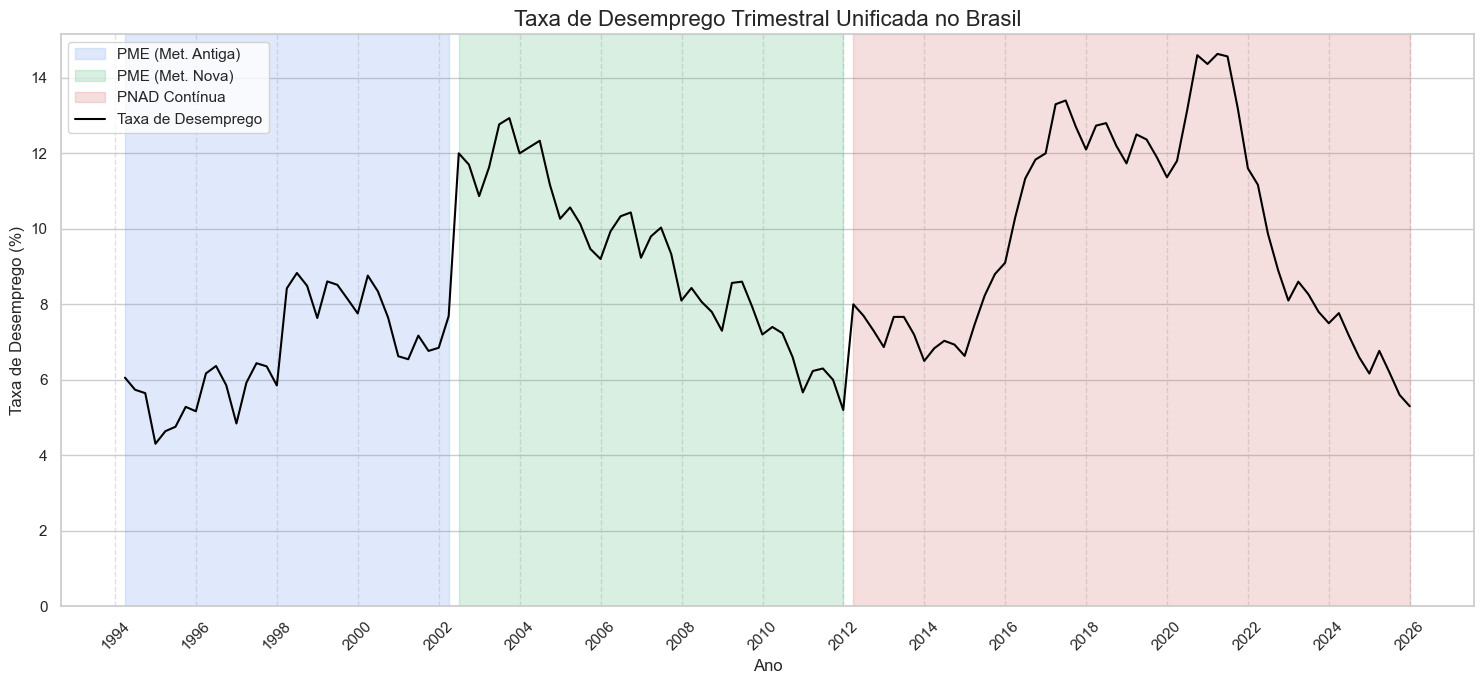

In [6]:
# --- CÓDIGO PARA GERAR O GRÁFICO DA SÉRIE UNIFICADA ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

try:
    # Configura um estilo visual mais agradável para o gráfico
    sns.set_theme(style="whitegrid")

    # Cria a figura e os eixos para o gráfico, com um bom tamanho
    fig, ax = plt.subplots(figsize=(15, 7))

    # --- Sombreado para indicar a metodologia de fundo ---
    # Usamos um zorder baixo para que o sombreado fique atrás da linha principal

    # Encontra as datas de início e fim para cada metodologia
    start_pme_antiga = desemprego_unificado[desemprego_unificado['metodologia'] == 'PME_Antiga'].index.min()
    end_pme_antiga = desemprego_unificado[desemprego_unificado['metodologia'] == 'PME_Antiga'].index.max()
    ax.axvspan(start_pme_antiga, end_pme_antiga, alpha=0.2, color='cornflowerblue', label='PME (Met. Antiga)', zorder=1)

    start_pme_nova = desemprego_unificado[desemprego_unificado['metodologia'] == 'PME_Nova'].index.min()
    end_pme_nova = desemprego_unificado[desemprego_unificado['metodologia'] == 'PME_Nova'].index.max()
    ax.axvspan(start_pme_nova, end_pme_nova, alpha=0.2, color='mediumseagreen', label='PME (Met. Nova)', zorder=1)

    start_pnadc = desemprego_unificado[desemprego_unificado['metodologia'] == 'PNADc'].index.min()
    end_pnadc = desemprego_unificado.index.max() # A PNADc vai até o final da série
    ax.axvspan(start_pnadc, end_pnadc, alpha=0.2, color='indianred', label='PNAD Contínua', zorder=1)

    # --- Linha Principal do Gráfico ---
    # Usamos um zorder alto para que a linha fique na frente do sombreado
    ax.plot(desemprego_unificado.index, desemprego_unificado['desemprego'], label='Taxa de Desemprego', color='black', linewidth=1.5, zorder=3)


    # --- Formatação e Títulos ---

    # Define o título e os rótulos dos eixos
    ax.set_title('Taxa de Desemprego Trimestral Unificada no Brasil', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Taxa de Desemprego (%)', fontsize=12)
    ax.set_ylim(bottom=0) # Garante que o eixo Y comece no 0

    # Formata o eixo x para mostrar os anos de forma clara
    ax.xaxis.set_major_locator(mdates.YearLocator(2)) # Marcador a cada 2 anos
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='x', linestyle='--', alpha=0.6) # Adiciona grades verticais

    # Adiciona a legenda
    ax.legend(loc='upper left')

    # Melhora o layout para não cortar os rótulos
    plt.tight_layout()

    # Exibe o gráfico
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico: {e}")
    print("Verifique se a célula anterior foi executada e o DataFrame 'desemprego_unificado' foi criado corretamente.")


In [7]:
# --- EXPORTAR DADOS TRATADOS ---

# Definir os nomes dos arquivos de saída
output_path_pkl = 'desemprego_tratado.pkl'
output_path_csv = 'desemprego_tratado.csv'

try:
    # Opção 1: Salvar em formato Pickle (recomendado)
    # Preserva todos os tipos de dados e o índice do pandas perfeitamente.
    desemprego_unificado.to_pickle(output_path_pkl)
    
    # Opção 2: Salvar em formato CSV
    # Bom para inspecionar os dados em outros softwares (como Excel).
    desemprego_unificado.to_csv(output_path_csv)
    
    print(f"Dados de desemprego exportados com sucesso para:")
    print(f"- {output_path_pkl} (Pickle)")
    print(f"- {output_path_csv} (CSV)")

except Exception as e:
    print(f"Ocorreu um erro ao exportar os dados: {e}")


Dados de desemprego exportados com sucesso para:
- desemprego_tratado.pkl (Pickle)
- desemprego_tratado.csv (CSV)
